# Initialize

In [7]:
#Imports
import os
import numpy as np
import yaml
import shutil
import re
import matplotlib.pyplot as plt
#Helper
def get_directories(directory, regex_search=""):
    """
    This function returns a list of directories from the specified directory that match the regular expression search pattern.
    
    Parameters:
    directory (str): The directory path where to look for directories.
    regex_search (str, optional): The regular expression pattern to match. Default is an empty string, which means all directories are included.
    
    Returns:
    list: A list of directory names that match the regular expression search pattern.
    """
    directories = None
    if os.path.exists(directory):
        directories = [name for name in os.listdir(directory) if os.path.isdir(os.path.join(directory, name)) and len(re.findall(regex_search, name))>0]
    else:
        print(f"Directory does not exist: {directory}")
    return directories

def traces(fluorescence, animal_id, session_id, unit_id="all", 
            num_cells="all", fluorescence_type="", fps=30, dpi=300):
    # plot fluorescence
    fluorescence = np.array(fluorescence)
    fluorescence = np.transpose(fluorescence) if len(fluorescence.shape)==2 else fluorescence
    plt.figure()
    plt.figure(figsize=(12, 7))
    if num_cells != "all":
        plt.plot(fluorescence[:, :int(num_cells)])
    else:
        plt.plot(fluorescence)

    seconds = 5
    num_frames = fps*seconds
    num_x_ticks = 50
    written_label_steps = 2

    x_time = [int(frame/num_frames)*seconds for frame in range(len(fluorescence)) if frame%num_frames==0] 
    steps = round(len(x_time)/(2*num_x_ticks))
    x_time_shortened = x_time[::steps]
    x_pos = np.arange(0, len(fluorescence), num_frames)[::steps] 
    
    file_name = f"{animal_id} {session_id}"
    title = f"Bursts from {file_name} {fluorescence_type}"
    xlabel=f"seconds"
    ylabel='fluorescence based on Ca in Cell'
    x_labels = [time if num%written_label_steps==0 else "" for num, time in enumerate(x_time_shortened)]
    plt.xticks(x_pos, x_labels, rotation=40, fontsize=8)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    #plt.savefig(os.path.join(self.save_dir, title.replace(" ", "_")+".png"), dpi=dpi)
    plt.show()
    plt.close()

#Classes
class Animal:
    """
    This class represents an animal in an experiment.

    Attributes:
    root_dir (str): The root directory where the data is stored.
    sessions (dict): A dictionary to store session objects for this animal.
    cohort_year (int): The year of the cohort that the animal belongs to.
    dob (str): The date of birth of the animal.
    animal_id (str): The ID of the animal.
    pdays (list of int): The postnatal days when the sessions were conducted.
    session_dates (list of str): The dates when the sessions were conducted.
    session_names (list of str): The names of the sessions.
    sex (str): The sex of the animal.

    Methods:
    load_data(yaml_path): Loads metadata for the animal from a YAML file.
    get_session_data(session_id, print_loading=True): Loads data for a specific session.
    """
    root_dir = "/scicore/projects/donafl00-calcium/Users/Sergej/Steffen_Experiments" 

    def __init__(self, yaml_file_path, print_loading=True) -> None:
        self.sessions = {}
        self.cohort_year = None
        self.dob = None
        self.animal_id = None 
        self.pdays = None 
        self.session_dates = None 
        self.session_names = None 
        self.sex = None 
        self.load_data(yaml_file_path)
        self.animal_dir = os.path.join(Animal.root_dir, self.animal_id)
        if print_loading:
            print(f"Loaded animal: {self.animal_id}")

    def load_data(self, yaml_path):
        with open(yaml_path, "r") as yaml_file:
            animal_metadata_dict = yaml.safe_load(yaml_file)
        self.cohort_year = int(animal_metadata_dict["cohort_year"])
        self.dob = animal_metadata_dict["dob"]
        self.animal_id = animal_metadata_dict["name"]
        self.pdays = [int(pday) for pday in animal_metadata_dict["pdays"]]
        self.session_dates = animal_metadata_dict["session_dates"]
        self.session_names = animal_metadata_dict["session_names"]
        self.sex = animal_metadata_dict["sex"]
    
    def get_session_data(self, session_id, print_loading=True):
        yaml_file_index = self.session_names.index(session_id)
        session = Session(self.animal_id, session_id, 
                          age=self.pdays[yaml_file_index], 
                          session_date=self.session_dates[yaml_file_index], 
                          print_loading=print_loading)
        self.sessions[session_id] = session

class Session:
    """
    A class that represents a session of an animal.

    Attributes
    ----------
    animal_id : str
        The ID of the animal.
    session_id : str
        The ID of the session.
    age : int
        The age of the animal during the session.
    session_date : str
        The date of the session.
    print_loading : bool, optional
        Whether to print a message when loading the session, by default True.

    Methods
    -------
    load_fluoresence()
        Loads fluorescence data from CaBincorr data.
    """
    cabincorr_fname = "binarized_traces.npz"

    def __init__(self, animal_id, session_id, age, session_date, print_loading=True):
        if print_loading:
            print(f"Loading session: {animal_id} {session_id}")
        self.animal_id = animal_id
        self.session_id = session_id
        self.session_date = session_date
        self.age = age
        self.session_dir = os.path.join(Animal.root_dir, animal_id, session_id)
        self.F_detrended, self.F_upphase = None, None
    
    def load_fluoresence(self):
        if self.F_detrended:
            return self.F_detrended, self.F_upphase
        F_detrended_path = os.path.join(self.session_dir, "F_detrended.npy")
        F_upphase_path = os.path.join(self.session_dir, "F_upphase.npy")
        self.F_detrended = np.load(F_detrended_path) if os.path.exists(F_detrended_path) else None
        self.F_upphase = np.load(F_upphase_path) if os.path.exists(F_upphase_path) else None
        return self.F_detrended, self.F_upphase

In [8]:
def load_all(root_dir, wanted_animal_ids=["all"], wanted_session_ids=["all"], print_loading=True):
    """
    Loads animal data from the specified root directory for the given animal IDs.

    Parameters:
    - root_dir (string): The root directory path where the animal data is stored.
    - animal_ids (list, optional): A list of animal IDs to load. Default is ["all"].
    Returns:
    - animals_dict (dict): A dictionary containing animal IDs as keys and corresponding Animal objects as values.
    """
    present_animal_ids = get_directories(root_dir, regex_search="DON-")
    animals_dict = {}

    # Search for animal_ids
    for animal_id in present_animal_ids:
        if animal_id in wanted_animal_ids or "all" in wanted_animal_ids:
            sessions_path = os.path.join(root_dir, animal_id)
            present_sessions = get_directories(sessions_path)
            yaml_file_name = os.path.join(root_dir, animal_id, f"{animal_id}.yaml")
            animal = Animal(yaml_file_name, print_loading=print_loading)
            Animal.root_dir = root_dir
            # Search for 2P Sessions
            for session in present_sessions:
                if session in wanted_session_ids or "all" in wanted_session_ids:
                    animal.get_session_data(session, print_loading=print_loading)
            animals_dict[animal_id] = animal
    return animals_dict

# Work Examples

In [9]:
# Root directory should be changed in Animal class too, if necessary
#root_dir = r"\\toucan-all.scicore.unibas.ch\donafl00-calcium$\Users\Sergej\Steffen_Experiments\rodrigo"
root_dir = "/scicore/projects/donafl00-calcium/Users/Sergej/Steffen_Experiments/cecillia" 
Animal.root_dir = root_dir
mice21 = ["DON-002865", "DON-003165", "DON-003343", "DON-006084", "DON-006085", "DON-006087"]
mice22 = ["DON-008497", "DON-008498", "DON-008499", "DON-009191", "DON-009192", "DON-010473", "DON-010477"]
mice23 = ["DON-014837", "DON-014838", "DON-014840", "DON-014847", "DON-014849", "DON-015078", "DON-015079"]

In [10]:
wanted_animal_ids = ["DON-002865"]
#wanted_animal_ids = mice21+mice22
animals = load_all(root_dir, wanted_animal_ids=wanted_animal_ids, wanted_session_ids=["all"], print_loading=True)

Loaded animal: DON-002865
Loading session: DON-002865 20210217
Loading session: DON-002865 20210227
Loading session: DON-002865 20210213
Loading session: DON-002865 20210223
Loading session: DON-002865 20210302
Loading session: DON-002865 20210218
Loading session: DON-002865 20210228
Loading session: DON-002865 20210211
Loading session: DON-002865 20210303
Loading session: DON-002865 20210216
Loading session: DON-002865 20210226
Loading session: DON-002865 20210222
Loading session: DON-002865 20210301
Loading session: DON-002865 20210214
Loading session: DON-002865 20210224
Loading session: DON-002865 20210210
Loading session: DON-002865 20210220
Loading session: DON-002865 20210219
Loading session: DON-002865 20210215
Loading session: DON-002865 20210225
Loading session: DON-002865 20210212


In [12]:
#wanted_animal_ids = ["DON-002865"]
wanted_animal_ids = mice21+mice22
animals = load_all(root_dir, wanted_animal_ids=wanted_animal_ids, wanted_session_ids=["all"], print_loading=False)

<Figure size 640x480 with 0 Axes>

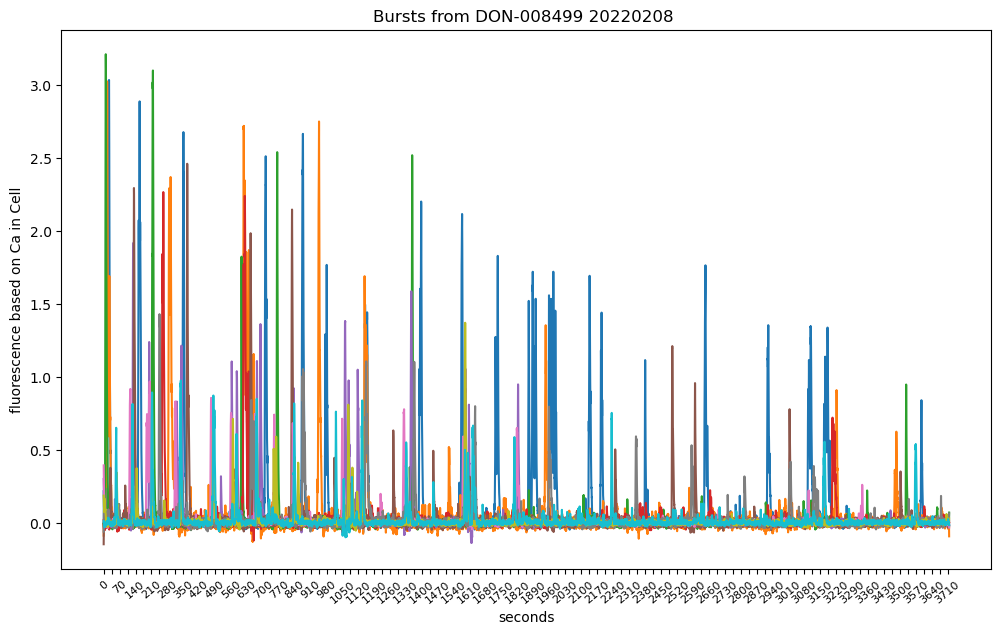

<Figure size 640x480 with 0 Axes>

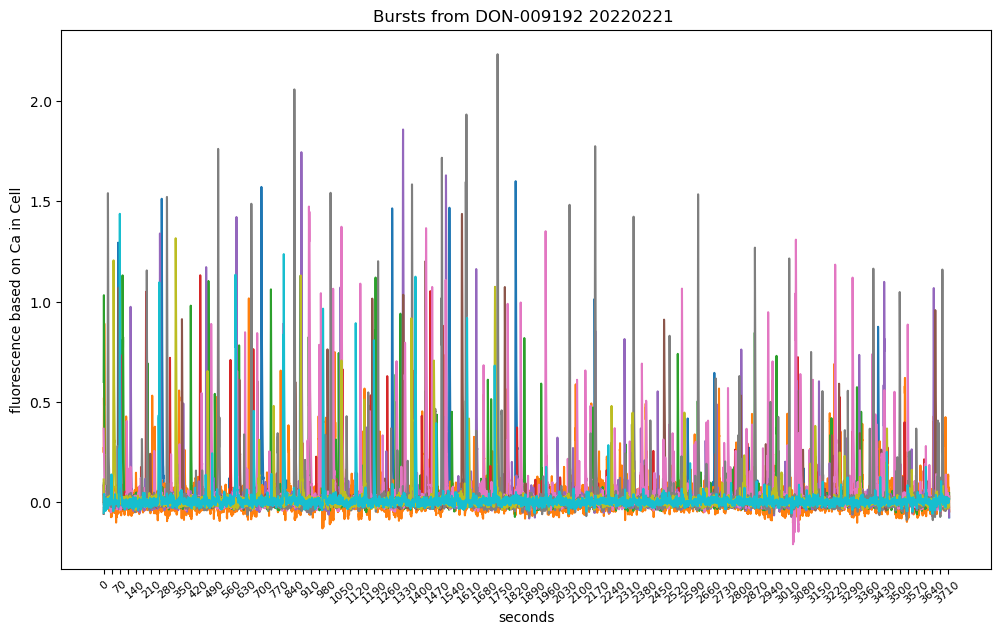

<Figure size 640x480 with 0 Axes>

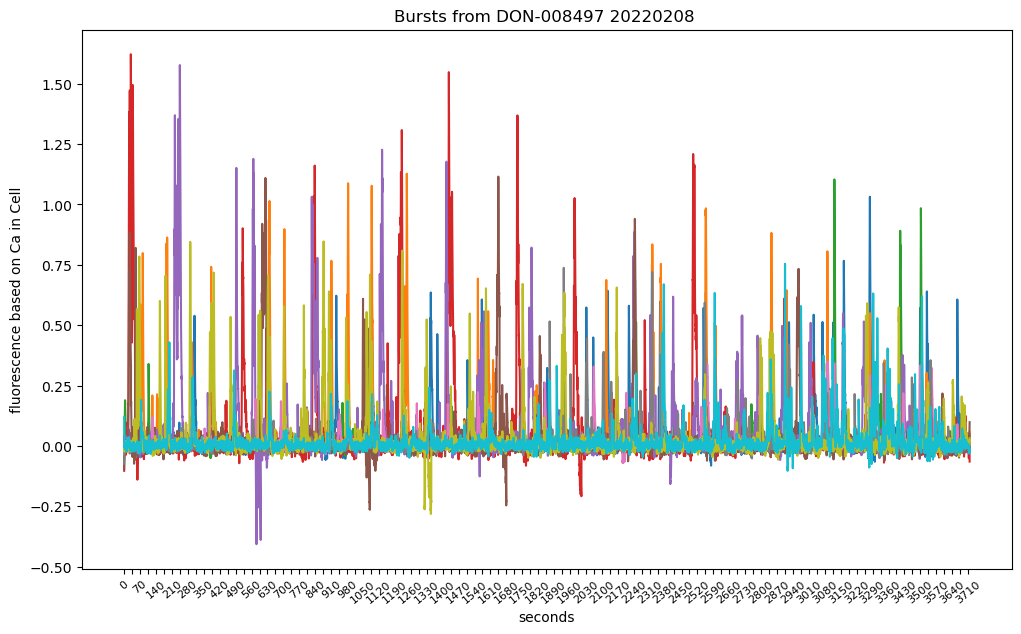

<Figure size 640x480 with 0 Axes>

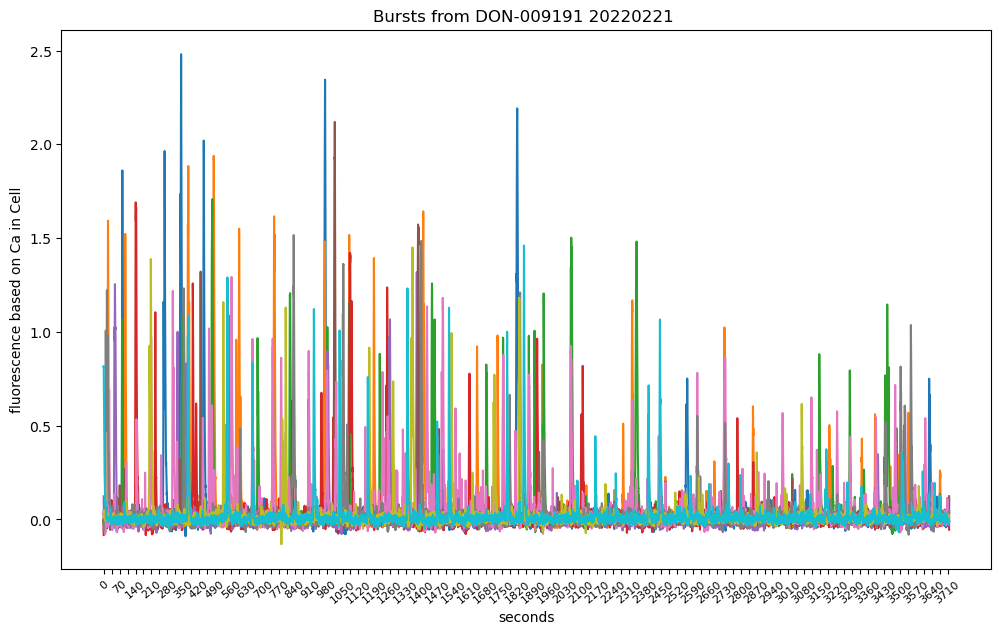

<Figure size 640x480 with 0 Axes>

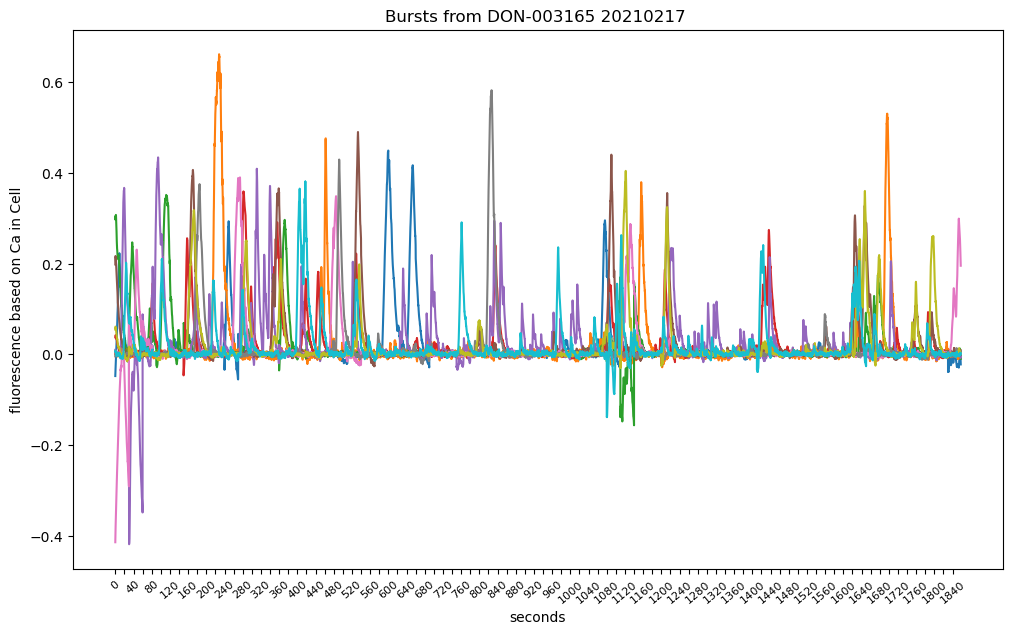

<Figure size 640x480 with 0 Axes>

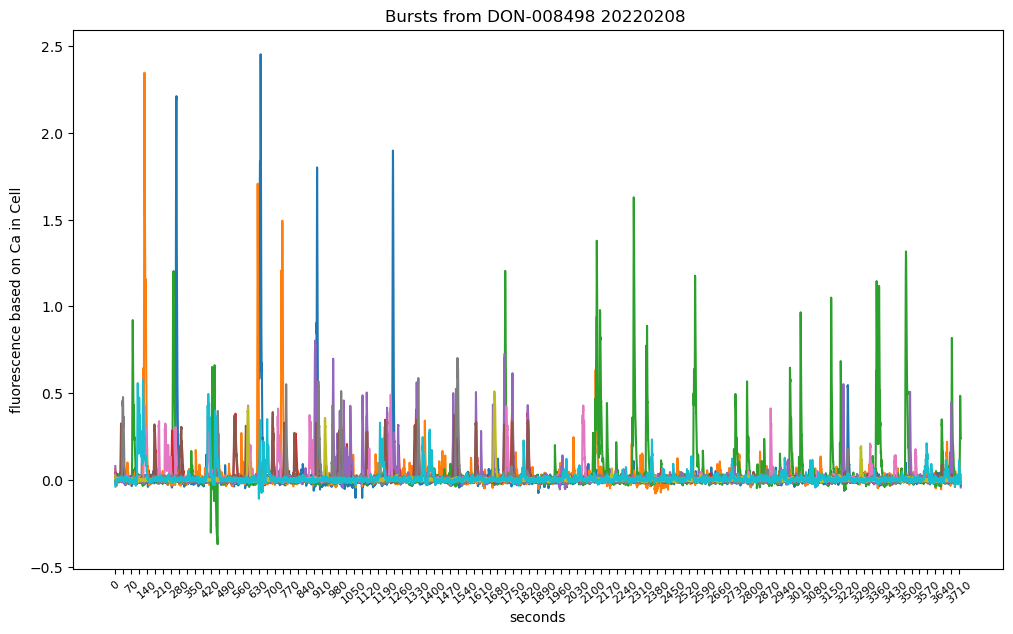

<Figure size 640x480 with 0 Axes>

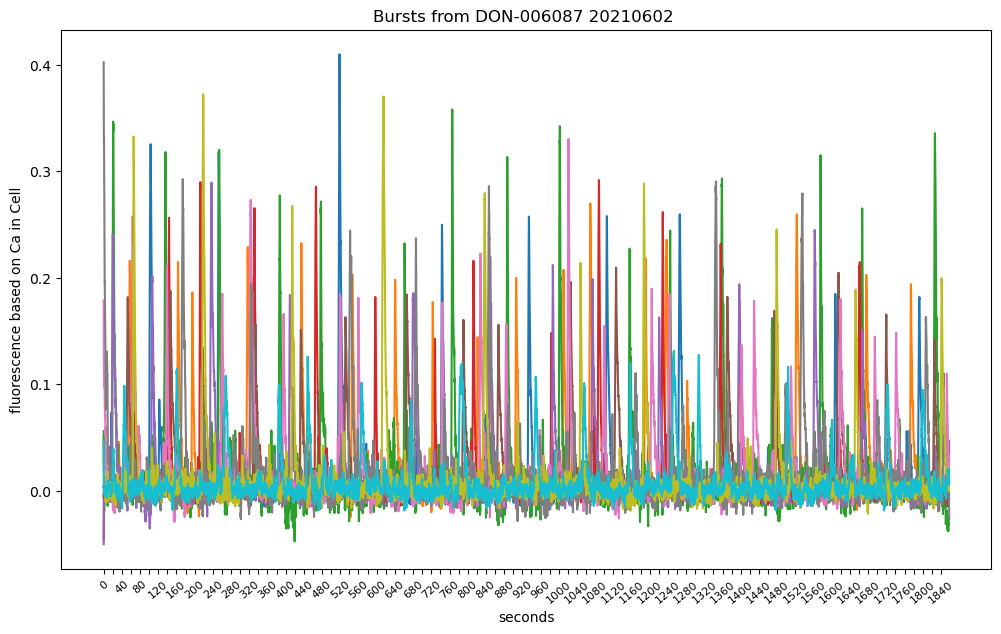

<Figure size 640x480 with 0 Axes>

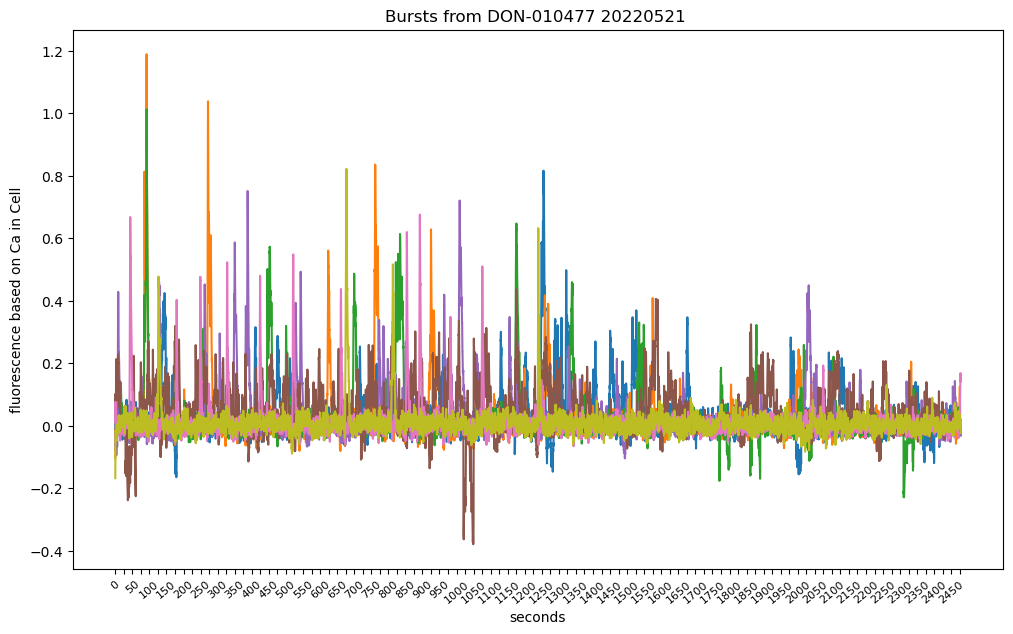

<Figure size 640x480 with 0 Axes>

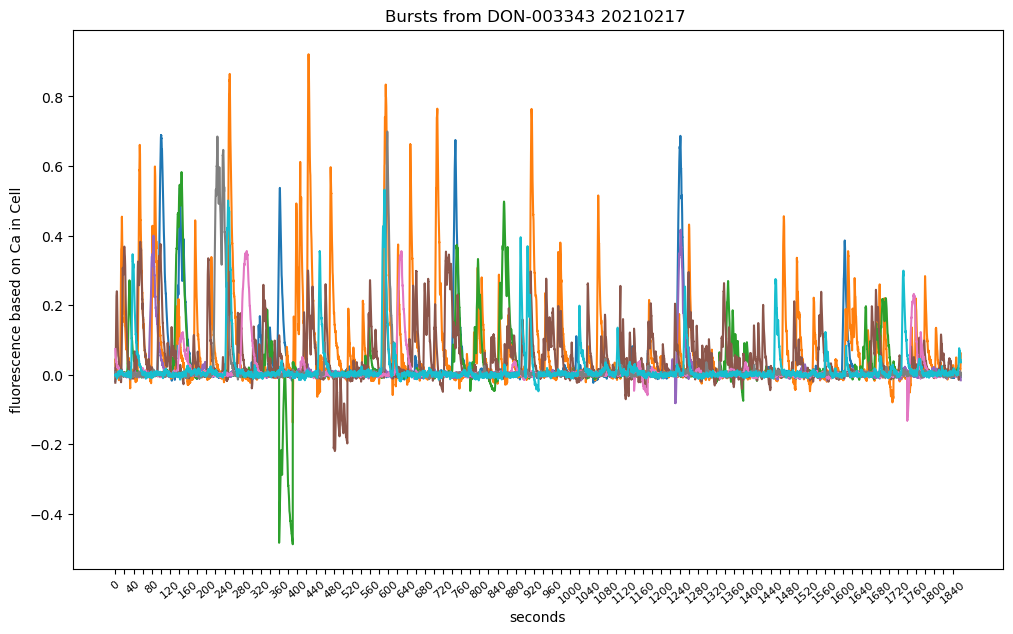

<Figure size 640x480 with 0 Axes>

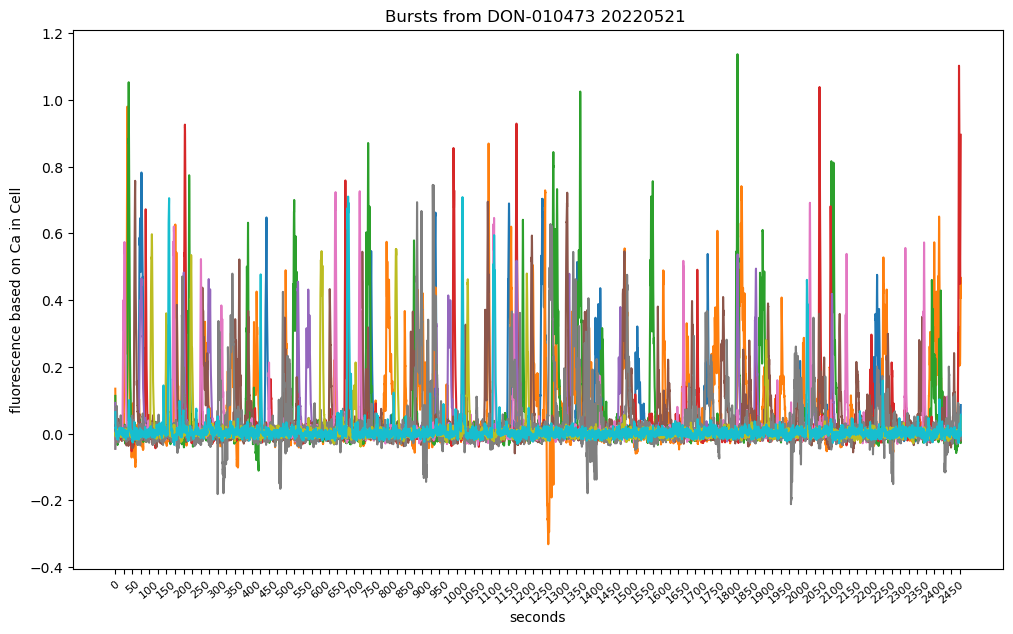

<Figure size 640x480 with 0 Axes>

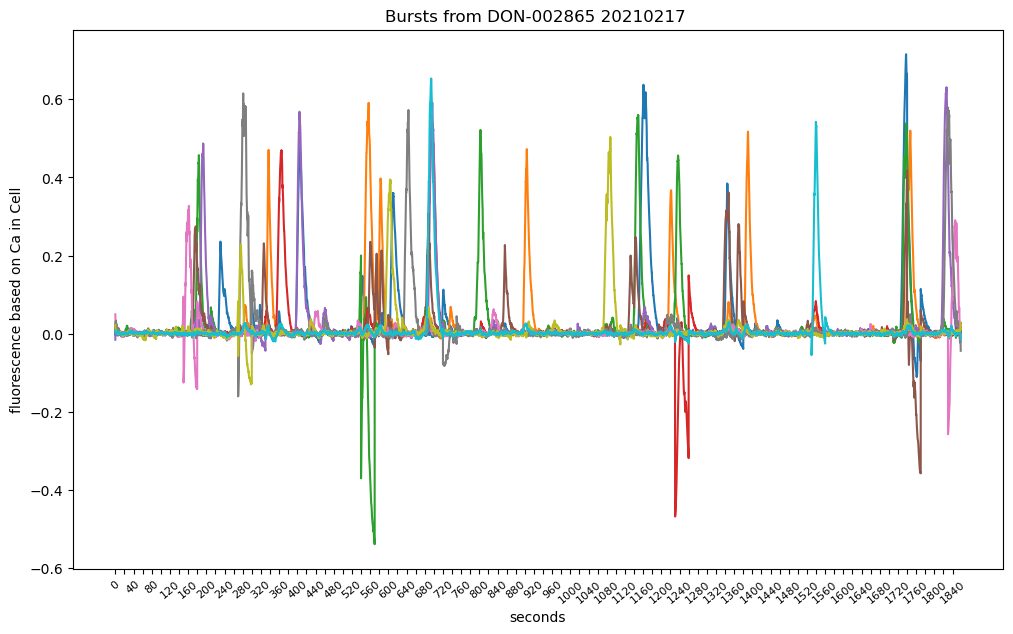

<Figure size 640x480 with 0 Axes>

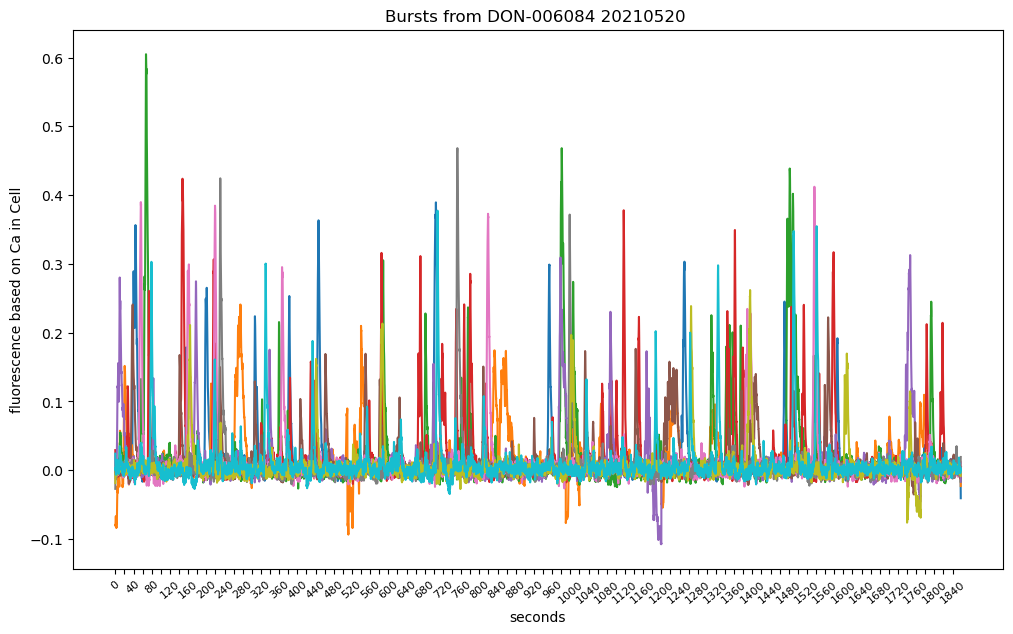

<Figure size 640x480 with 0 Axes>

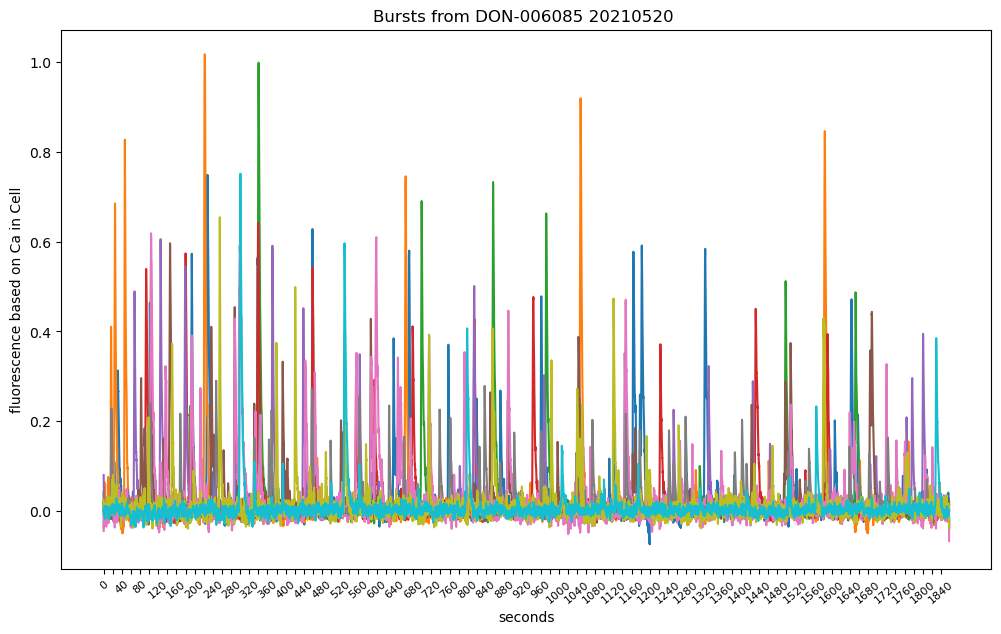

In [13]:
for animal_id, animal in animals.items():
    if animal.cohort_year in [2021, 2022]:
        for session_id, session in animal.sessions.items():
            session.load_fluoresence()
            traces(session.F_detrended, session.animal_id, session.session_id, num_cells=10)
            break